In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path(".")
OUTPUT_ROOT = PROJECT_ROOT / "outputs"
RESULTS_ROOT = OUTPUT_ROOT / "results_workzone"
DATA_PATH = PROJECT_ROOT / "data" / "workzone_traj_motion_agents_map.npz"

PLOT_DIR = OUTPUT_ROOT / "notebook_analysis_plots"
PLOT_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 220)
pd.set_option("display.max_colwidth", 120)

print("Project root:", PROJECT_ROOT.resolve())
print("Results root exists:", RESULTS_ROOT.exists())
print("Data exists:", DATA_PATH.exists())

Project root: /workspaces/Project
Results root exists: True
Data exists: True


In [21]:
def load_all_summary_tables(results_root=RESULTS_ROOT):
    summary_files = sorted(
        p for p in results_root.rglob("*_summary.csv")
        if p.name != "all_methods_summary.csv"
    )

    rows = []

    for path in summary_files:
        df = pd.read_csv(path)

        if df.empty:
            continue

        for col in ["method_group", "summary_file"]:
            if col in df.columns:
                df = df.drop(columns=[col])

        df.insert(0, "method_group", path.parent.name)
        df.insert(1, "summary_file", str(path))

        rows.append(df)

    if not rows:
        raise RuntimeError("No summary files found.")

    combined = pd.concat(rows, ignore_index=True, sort=False)

    combined["eval_ade"] = np.nan
    combined["eval_fde"] = np.nan

    if "min_ade" in combined.columns:
        combined["eval_ade"] = combined["min_ade"]

    if "min_fde" in combined.columns:
        combined["eval_fde"] = combined["min_fde"]

    if "ade" in combined.columns:
        combined["eval_ade"] = combined["eval_ade"].fillna(combined["ade"])

    if "fde" in combined.columns:
        combined["eval_fde"] = combined["eval_fde"].fillna(combined["fde"])

    combined = combined.sort_values(
        ["eval_ade", "eval_fde"],
        na_position="last"
    ).reset_index(drop=True)

    return combined


def get_clean_method_label(row):
    method_group = str(row.get("method_group", "")).lower()
    method = str(row.get("method", "")).lower()

    # Learned models
    if "lstm" in method_group or "lstm" in method:
        return "LSTM"

    if "gru" in method_group or "gru" in method:
        return "GRU"

    if "transformer" in method_group or "transformer" in method:
        return "Transformer"

    if "mlp" in method_group or "mlp" in method:
        return "MLP"

    # Classical ML
    if "ridge" in method:
        return "Ridge Regression"

    if "linear_regression" in method_group or "linear_regression" in method:
        return "Linear Regression"

    # Physics / filtering baselines
    if "ekf" in method or "ctrv" in method:
        return "EKF CTRV"

    if "kalman" in method_group or "kalman" in method:
        return "Kalman Filter CV"

    if "constant_velocity" in method_group or "constant_velocity" in method:
        return "Constant Velocity"

    if "constant_acceleration" in method_group or "constant_acceleration" in method:
        return "Constant Acceleration"

    if "stationary" in method_group or "stationary" in method:
        return "Stationary"

    # Fallback
    return str(row.get("method_group", row.get("method", "Unknown")))


all_results = load_all_summary_tables()

# Add clean method labels
all_results["method_label"] = all_results.apply(get_clean_method_label, axis=1)

# Pick best row per clean method label
best_per_method = (
    all_results
    .sort_values(["method_label", "eval_ade", "eval_fde"], na_position="last")
    .groupby("method_label", as_index=False)
    .first()
    .sort_values(["eval_ade", "eval_fde"], na_position="last")
    .reset_index(drop=True)
)

display_cols = [
    "method_label",
    "method_group",
    "method",
    "eval_ade",
    "eval_fde",
    "ade",
    "fde",
    "min_ade",
    "min_fde",
    "conf_ade",
    "conf_fde",
    "num_samples",
]

display_cols = [c for c in display_cols if c in all_results.columns]

print("BEST RESULT PER METHOD")
display(best_per_method[display_cols])

print("ALL BASELINE RESULTS")
display(all_results[display_cols])

best_out_path = OUTPUT_ROOT / "best_per_method_summary_notebook.csv"
all_out_path = OUTPUT_ROOT / "all_methods_summary_notebook.csv"

best_per_method.to_csv(best_out_path, index=False)
all_results.to_csv(all_out_path, index=False)

print("Saved best per method:", best_out_path)
print("Saved all results:", all_out_path)

BEST RESULT PER METHOD


,method_label,method_group,method,eval_ade,eval_fde,ade,fde,min_ade,min_fde,conf_ade,conf_fde,num_samples
0,LSTM,lstm_topk_conf,lstm_top6_conf_hidden_256_layers_2,2.011838,4.174666,NaN,NaN,2.011838,4.174666,4.974311,11.734148,1131
1,Transformer,transformer,transformer_d64_heads_4_layers_1_ff_128_lr_0p0003,3.658571,8.935156,3.658571,8.935156,NaN,NaN,NaN,NaN,1131
2,Linear Regression,linear_regression,linear_regression,3.902141,10.289408,3.902141,10.289408,NaN,NaN,NaN,NaN,1131
3,Ridge Regression,linear_regression,ridge_regression,3.993083,10.445417,3.993083,10.445417,NaN,NaN,NaN,NaN,1131
4,MLP,mlp,mlp_hidden_64,4.164154,10.347683,4.164154,10.347683,NaN,NaN,NaN,NaN,1131
5,GRU,gru,gru_hidden_256_layers_2,4.522870,10.864872,4.522870,10.864872,NaN,NaN,NaN,NaN,1131
6,EKF CTRV,kalman_filter,ekf_ctrv,5.515941,14.587195,5.515941,14.587195,NaN,NaN,NaN,NaN,1131
7,Constant Velocity,constant_velocity,constant_velocity_smoothed,8.188560,19.009969,8.188560,19.009969,NaN,NaN,NaN,NaN,1131
8,Kalman Filter CV,kalman_filter,kalman_cv,8.330958,19.095455,8.330958,19.095455,NaN,NaN,NaN,NaN,1131
9,Constant Acceleration,constant_acceleration,constant_acceleration_smoothed,9.667328,26.674775,9.667328,26.674775,NaN,NaN,NaN,NaN,1131


ALL BASELINE RESULTS


,method_label,method_group,method,eval_ade,eval_fde,ade,fde,min_ade,min_fde,conf_ade,conf_fde,num_samples
0,LSTM,lstm_topk_conf,lstm_top6_conf_hidden_256_layers_2,2.011838,4.174666,NaN,NaN,2.011838,4.174666,4.974311,11.734148,1131
1,LSTM,lstm_v4_map_workzone_best,lstm_top6_conf_hidden_256_layers_2,2.011838,4.174666,NaN,NaN,2.011838,4.174666,4.974311,11.734148,1131
2,LSTM,lstm_v2_ego_motion_best,lstm_top6_conf_hidden_256_layers_2,2.064643,4.850482,NaN,NaN,2.064643,4.850482,4.632413,12.441382,1131
3,LSTM,lstm_topk_conf,lstm_top6_conf_hidden_256_layers_1,2.087077,4.507918,NaN,NaN,2.087077,4.507918,5.018113,12.079676,1131
4,LSTM,lstm_v3_agent_context_best,lstm_top6_conf_hidden_256_layers_2,2.228301,5.099242,NaN,NaN,2.228301,5.099242,4.527508,11.673483,1131
5,LSTM,lstm_topk_conf,lstm_top6_conf_hidden_256_layers_3,2.248925,4.225373,NaN,NaN,2.248925,4.225373,6.465422,14.180730,1131
6,LSTM,lstm_topk_conf,lstm_top6_conf_hidden_128_layers_3,2.282879,4.859890,NaN,NaN,2.282879,4.859890,5.456032,12.713124,1131
7,LSTM,lstm_topk_conf,lstm_top6_conf_hidden_128_layers_2,2.379788,5.492911,NaN,NaN,2.379788,5.492911,4.935996,11.932338,1131
8,LSTM,lstm_topk_conf,lstm_top6_conf_hidden_64_layers_1,2.437939,5.534382,NaN,NaN,2.437939,5.534382,4.557653,10.974682,1131
9,LSTM,lstm_topk_conf,lstm_top6_conf_hidden_128_layers_1,2.443097,5.078548,NaN,NaN,2.443097,5.078548,5.123041,11.953090,1131


Saved best per method: outputs/best_per_method_summary_notebook.csv
Saved all results: outputs/all_methods_summary_notebook.csv


In [ ]:
def load_all_summary_tables(results_root=RESULTS_ROOT):
    summary_files = sorted(
        p for p in results_root.rglob("*_summary.csv")
        if p.name != "all_methods_summary.csv"
    )

    rows = []

    for path in summary_files:
        df = pd.read_csv(path)

        if df.empty:
            continue

        for col in ["method_group", "summary_file"]:
            if col in df.columns:
                df = df.drop(columns=[col])

        df.insert(0, "method_group", path.parent.name)
        df.insert(1, "summary_file", str(path))

        rows.append(df)

    if not rows:
        raise RuntimeError("No summary files found.")

    combined = pd.concat(rows, ignore_index=True, sort=False)

    combined["eval_ade"] = np.nan
    combined["eval_fde"] = np.nan

    if "min_ade" in combined.columns:
        combined["eval_ade"] = combined["min_ade"]

    if "min_fde" in combined.columns:
        combined["eval_fde"] = combined["min_fde"]

    if "ade" in combined.columns:
        combined["eval_ade"] = combined["eval_ade"].fillna(combined["ade"])

    if "fde" in combined.columns:
        combined["eval_fde"] = combined["eval_fde"].fillna(combined["fde"])

    combined = combined.sort_values(
        ["eval_ade", "eval_fde"],
        na_position="last"
    ).reset_index(drop=True)

    return combined


def get_clean_method_label(row):
    method_group = str(row.get("method_group", "")).lower()
    method = str(row.get("method", "")).lower()

    # LSTM variants should stay separate
    if method_group == "lstm_v1_traj_only_best":
        return "LSTM - Trajectory Only"

    if method_group == "lstm_v2_ego_motion_best":
        return "LSTM - Ego Motion"

    if method_group == "lstm_v3_agent_context_best":
        return "LSTM - Agent Context"

    if method_group == "lstm_v4_map_workzone_best":
        return "LSTM - Map + Workzone"

    if method_group == "lstm_topk_conf":
        return "LSTM - Top-K Confidence"

    # Other learned models
    if "gru" in method_group or "gru" in method:
        return "GRU"

    if "transformer" in method_group or "transformer" in method:
        return "Transformer"

    if "mlp" in method_group or "mlp" in method:
        return "MLP"

    # Classical ML
    if method == "ridge_regression":
        return "Ridge Regression"

    if method == "linear_regression":
        return "Linear Regression"

    # Physics / filtering baselines
    if method == "ekf_ctrv":
        return "EKF CTRV"

    if method == "kalman_cv":
        return "Kalman Filter CV"

    if "constant_velocity" in method_group or "constant_velocity" in method:
        return "Constant Velocity"

    if "constant_acceleration" in method_group or "constant_acceleration" in method:
        return "Constant Acceleration"

    if "stationary" in method_group or "stationary" in method:
        return "Stationary"

    return str(row.get("method_group", row.get("method", "Unknown")))


all_results = load_all_summary_tables()

all_results["method_label"] = all_results.apply(get_clean_method_label, axis=1)

best_per_method = (
    all_results
    .sort_values(
        ["method_label", "eval_ade", "eval_fde"],
        na_position="last"
    )
    .groupby("method_label", as_index=False)
    .first()
    .sort_values(
        ["eval_ade", "eval_fde"],
        na_position="last"
    )
    .reset_index(drop=True)
)

display_cols = [
    "method_label",
    "method_group",
    "method",
    "eval_ade",
    "eval_fde",
    "ade",
    "fde",
    "min_ade",
    "min_fde",
    "conf_ade",
    "conf_fde",
    "num_samples",
]

display_cols = [c for c in display_cols if c in all_results.columns]

print("BEST RESULT PER METHOD / EXPERIMENT TYPE")
display(best_per_method[display_cols])

print("ALL BASELINE RESULTS")
display(all_results[display_cols])

best_out_path = OUTPUT_ROOT / "best_per_method_summary_notebook.csv"
all_out_path = OUTPUT_ROOT / "all_methods_summary_notebook.csv"

best_per_method.to_csv(best_out_path, index=False)
all_results.to_csv(all_out_path, index=False)

print("Saved best per method:", best_out_path)
print("Saved all results:", all_out_path)

BEST METHOD FROM EACH METHOD GROUP


,method_group,method,eval_ade,eval_fde,ade,fde,min_ade,min_fde,conf_ade,conf_fde,num_samples
5,lstm_topk_conf,lstm_top6_conf_hidden_256_layers_2,2.011838,4.174666,NaN,NaN,2.011838,4.174666,4.974311,11.734148,1131
9,lstm_v4_map_workzone_best,lstm_top6_conf_hidden_256_layers_2,2.011838,4.174666,NaN,NaN,2.011838,4.174666,4.974311,11.734148,1131
7,lstm_v2_ego_motion_best,lstm_top6_conf_hidden_256_layers_2,2.064643,4.850482,NaN,NaN,2.064643,4.850482,4.632413,12.441382,1131
8,lstm_v3_agent_context_best,lstm_top6_conf_hidden_256_layers_2,2.228301,5.099242,NaN,NaN,2.228301,5.099242,4.527508,11.673483,1131
6,lstm_v1_traj_only_best,lstm_top6_conf_hidden_256_layers_2,2.614684,5.490086,NaN,NaN,2.614684,5.490086,6.434547,15.064580,1131
12,transformer,transformer_d64_heads_4_layers_1_ff_128_lr_0p0003,3.658571,8.935156,3.658571,8.935156,NaN,NaN,NaN,NaN,1131
4,linear_regression,linear_regression,3.902141,10.289408,3.902141,10.289408,NaN,NaN,NaN,NaN,1131
10,mlp,mlp_hidden_64,4.164154,10.347683,4.164154,10.347683,NaN,NaN,NaN,NaN,1131
2,gru,gru_hidden_256_layers_2,4.522870,10.864872,4.522870,10.864872,NaN,NaN,NaN,NaN,1131
3,kalman_filter,ekf_ctrv,5.515941,14.587195,5.515941,14.587195,NaN,NaN,NaN,NaN,1131


Saved: outputs/best_method_per_group.csv


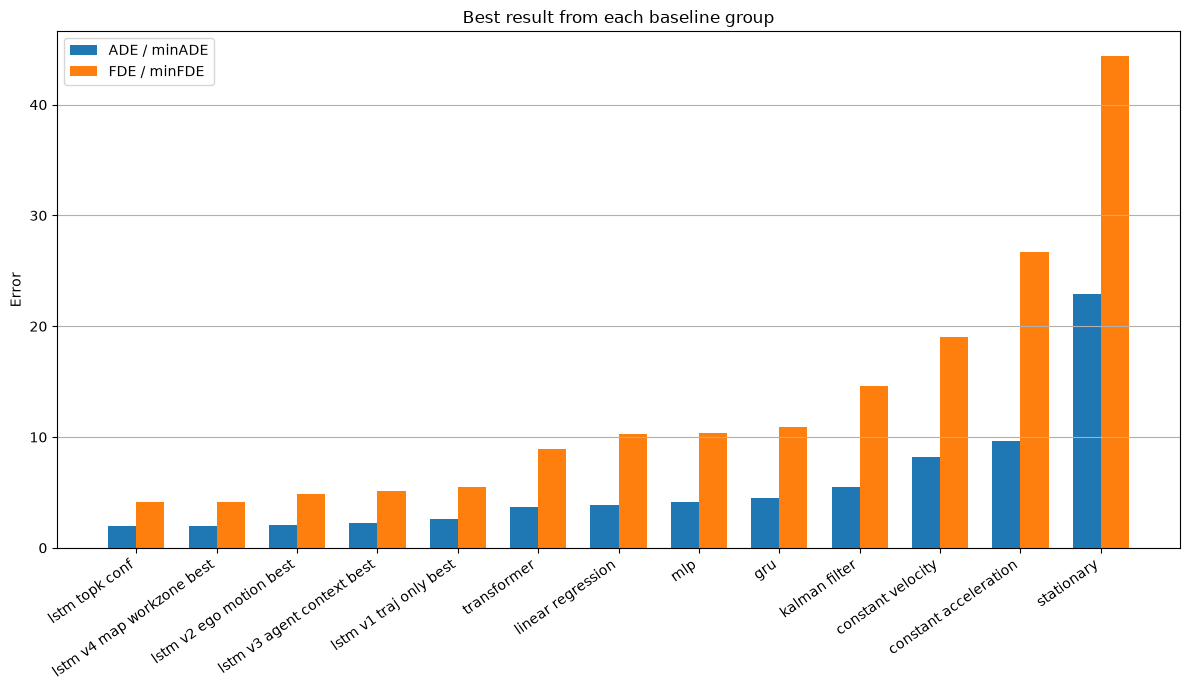

Saved: outputs/notebook_analysis_plots/best_method_per_group_ade_fde.png


In [4]:
plot_df = best_per_group.copy()

# Cleaner labels
plot_df["label"] = plot_df["method_group"].str.replace("_", " ", regex=False)

plt.figure(figsize=(12, 7))

x = np.arange(len(plot_df))
width = 0.35

plt.bar(x - width / 2, plot_df["eval_ade"], width, label="ADE / minADE")
plt.bar(x + width / 2, plot_df["eval_fde"], width, label="FDE / minFDE")

plt.xticks(x, plot_df["label"], rotation=35, ha="right")
plt.ylabel("Error")
plt.title("Best result from each baseline group")
plt.legend()
plt.grid(axis="y")
plt.tight_layout()

save_path = PLOT_DIR / "best_method_per_group_ade_fde.png"
plt.savefig(save_path, dpi=200)
plt.show()

print("Saved:", save_path)

DETERMINISTIC / SINGLE-TRAJECTORY BASELINES


,method_group,method,eval_ade,eval_fde,num_samples
30,transformer,transformer_d64_heads_4_layers_1_ff_128_lr_0p0003,3.658571,8.935156,1131
13,linear_regression,linear_regression,3.902141,10.289408,1131
31,transformer,transformer_d128_heads_4_layers_1_ff_256_lr_0p0003,3.970481,9.789467,1131
14,linear_regression,ridge_regression,3.993083,10.445417,1131
26,mlp,mlp_hidden_64,4.164154,10.347683,1131
28,mlp,mlp_hidden_256,4.186887,10.015342,1131
27,mlp,mlp_hidden_128,4.230708,10.249908,1131
32,transformer,transformer_d128_heads_4_layers_2_ff_256_lr_0p0003,4.309342,10.540982,1131
33,transformer,transformer_d128_heads_4_layers_2_ff_512_lr_0p0003,4.348426,10.546184,1131
8,gru,gru_hidden_256_layers_2,4.522870,10.864872,1131


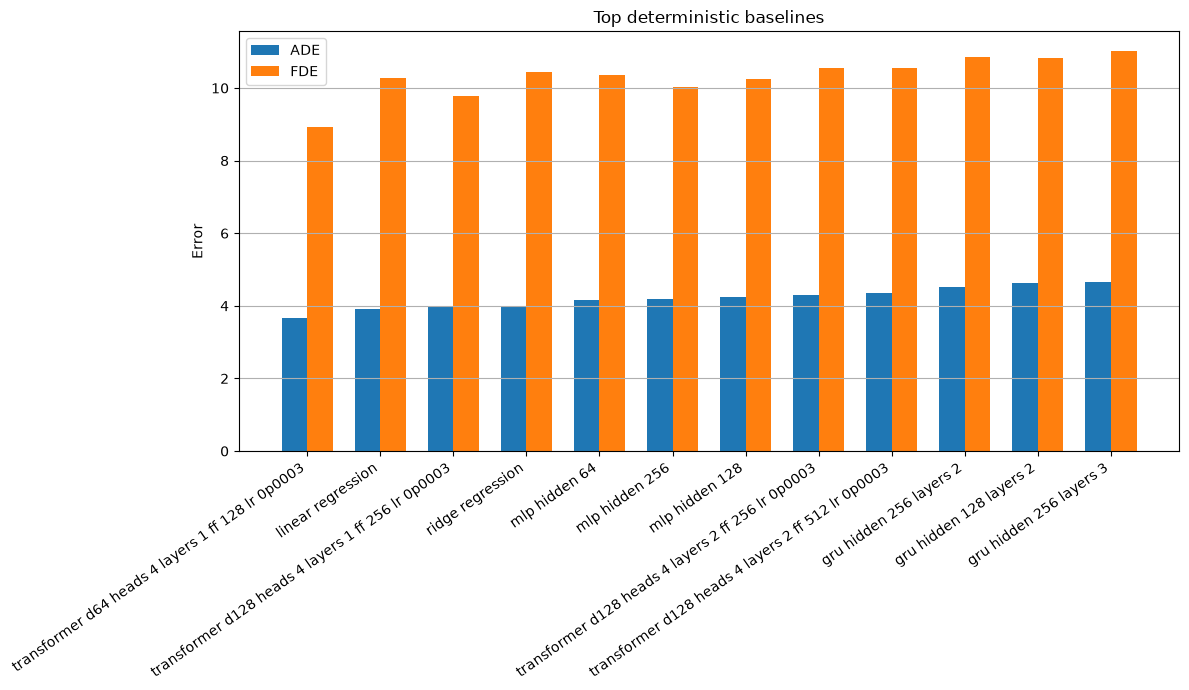

Saved: outputs/notebook_analysis_plots/deterministic_baselines_ade_fde.png


In [5]:
deterministic = all_results[
    ~all_results["method_group"].str.contains("lstm_topk|lstm_v", case=False, regex=True)
].copy()

deterministic = deterministic.sort_values(["eval_ade", "eval_fde"])

cols = [
    "method_group",
    "method",
    "eval_ade",
    "eval_fde",
    "num_samples",
]

print("DETERMINISTIC / SINGLE-TRAJECTORY BASELINES")
display(deterministic[cols])

plt.figure(figsize=(12, 7))

top_det = deterministic.head(12).copy()
top_det["label"] = top_det["method"].str.replace("_", " ", regex=False)

x = np.arange(len(top_det))
width = 0.35

plt.bar(x - width / 2, top_det["eval_ade"], width, label="ADE")
plt.bar(x + width / 2, top_det["eval_fde"], width, label="FDE")

plt.xticks(x, top_det["label"], rotation=35, ha="right")
plt.ylabel("Error")
plt.title("Top deterministic baselines")
plt.legend()
plt.grid(axis="y")
plt.tight_layout()

save_path = PLOT_DIR / "deterministic_baselines_ade_fde.png"
plt.savefig(save_path, dpi=200)
plt.show()

print("Saved:", save_path)

In [20]:
def load_horizon_tables(results_root=RESULTS_ROOT):
    horizon_files = sorted(results_root.rglob("*horizon*.csv"))

    rows = []

    for path in horizon_files:
        df = pd.read_csv(path)

        if df.empty:
            continue

        df.insert(0, "method_group", path.parent.name)
        df.insert(1, "horizon_file", str(path))
        rows.append(df)

    if not rows:
        raise RuntimeError("No horizon files found.")

    return pd.concat(rows, ignore_index=True, sort=False)


horizon_results = load_horizon_tables()

horizon_cols = [c for c in horizon_results.columns if c.startswith("err_")]
horizon_times = np.arange(1, len(horizon_cols) + 1) * 0.2

print("HORIZON ERROR TABLE")
display(horizon_results[["method_group", "method"] + horizon_cols])

horizon_results.to_csv(OUTPUT_ROOT / "all_horizon_errors_notebook.csv", index=False)
print("Saved:", OUTPUT_ROOT / "all_horizon_errors_notebook.csv")

HORIZON ERROR TABLE


,method_group,method,err_0p2s,err_0p4s,err_0p6000000000000001s,err_0p8s,err_1p0s,err_1p2000000000000002s,err_1p4000000000000001s,err_1p6s,err_1p8s,err_2p0s,err_2p2s,err_2p4000000000000004s,err_2p6s,err_2p8000000000000003s,err_3p0s,err_3p2s,err_3p4000000000000004s,err_3p6s,err_3p8000000000000003s,err_4p0s,err_4p2s,err_4p4s,err_4p6000000000000005s,err_4p800000000000001s,err_5p0s,err_0p6s,err_1p2s,err_1p4s,err_2p4s,err_2p8s,err_3p4s,err_3p8s,err_4p6s,err_4p8s
0,constant_acceleration,constant_acceleration_last_step,0.887485,2.266247,4.127477,6.489686,9.695741,13.599351,17.955882,22.942875,28.711351,35.145285,42.054860,49.647079,57.989233,66.923238,76.433065,86.623973,97.503714,108.980251,121.084932,133.869938,147.289421,161.323364,176.025016,191.365616,207.350360,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,constant_acceleration,constant_acceleration_smoothed,0.546788,0.809386,0.979004,1.265612,1.706554,2.169728,2.607218,3.177951,3.878935,4.647714,5.415919,6.327905,7.380483,8.488485,9.647035,10.935980,12.345964,13.805990,15.345679,17.028437,18.783136,20.609351,22.541274,24.563901,26.674775,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,constant_velocity,constant_velocity_last_step,0.642262,1.195039,1.545582,1.830044,2.450479,3.067135,3.475974,4.019168,4.744308,5.423892,6.028856,6.768742,7.585401,8.355263,9.152288,10.019267,10.920844,11.817206,12.762439,13.724163,14.710000,15.731469,16.775732,17.818610,18.904190,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,constant_velocity,constant_velocity_smoothed,0.561609,0.856588,1.113497,1.539252,2.062319,2.573065,3.120457,3.731944,4.395572,5.067222,5.771985,6.526797,7.326999,8.135281,8.985767,9.873052,10.786101,11.719049,12.690253,13.685493,14.704861,15.751467,16.823440,17.901955,19.009969,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,gru,gru_hidden_64_layers_1,0.361986,0.475576,0.465222,0.583854,0.802160,1.037519,1.347721,1.711826,2.100215,2.547434,3.042125,3.550551,4.078091,4.654346,5.241044,5.849320,6.465908,7.103505,7.731523,8.379078,9.021281,9.669071,10.308948,10.953603,11.598716,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,gru,gru_hidden_128_layers_1,0.364775,0.375176,0.424537,0.625512,0.852862,1.123309,1.481003,1.859064,2.269991,2.740872,3.243983,3.736921,4.270103,4.845222,5.432956,6.010151,6.623130,7.254659,7.878267,8.504725,9.137835,9.790313,10.438996,11.077448,11.709184,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,gru,gru_hidden_256_layers_1,0.310538,0.281778,0.398240,0.567161,0.758608,1.025319,1.354886,1.714231,2.118064,2.594801,3.103076,3.622285,4.177110,4.759612,5.375895,6.003233,6.645097,7.289582,7.953843,8.621941,9.271561,9.924337,10.593316,11.236419,11.862516,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,gru,gru_hidden_128_layers_2,0.427669,0.496387,0.525553,0.687700,0.928420,1.185207,1.488579,1.842392,2.243413,2.681900,3.134822,3.622961,4.129794,4.653293,5.169906,5.712918,6.269973,6.823255,7.377395,7.946158,8.540827,9.104201,9.673870,10.254616,10.828867,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,gru,gru_hidden_256_layers_2,0.365180,0.368842,0.521909,0.674018,0.873443,1.115875,1.435860,1.770705,2.119649,2.538171,2.978475,3.423837,3.890722,4.405879,4.942571,5.498904,6.064973,6.641469,7.253760,7.853875,8.453113,9.052751,9.678971,10.283933,10.864872,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,gru,gru_hidden_128_layers_3,0.417273,0.517952,0.584575,0.780461,1.033655,1.282422,1.595460,1.952901,2.338260,2.729739,3.171700,3.644978,4.130398,4.626065,5.141691,5.696103,6.242290,6.805898,7.384727,7.971084,8.562182,9.165142,9.772030,10.355369,10.958040,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Saved: outputs/all_horizon_errors_notebook.csv


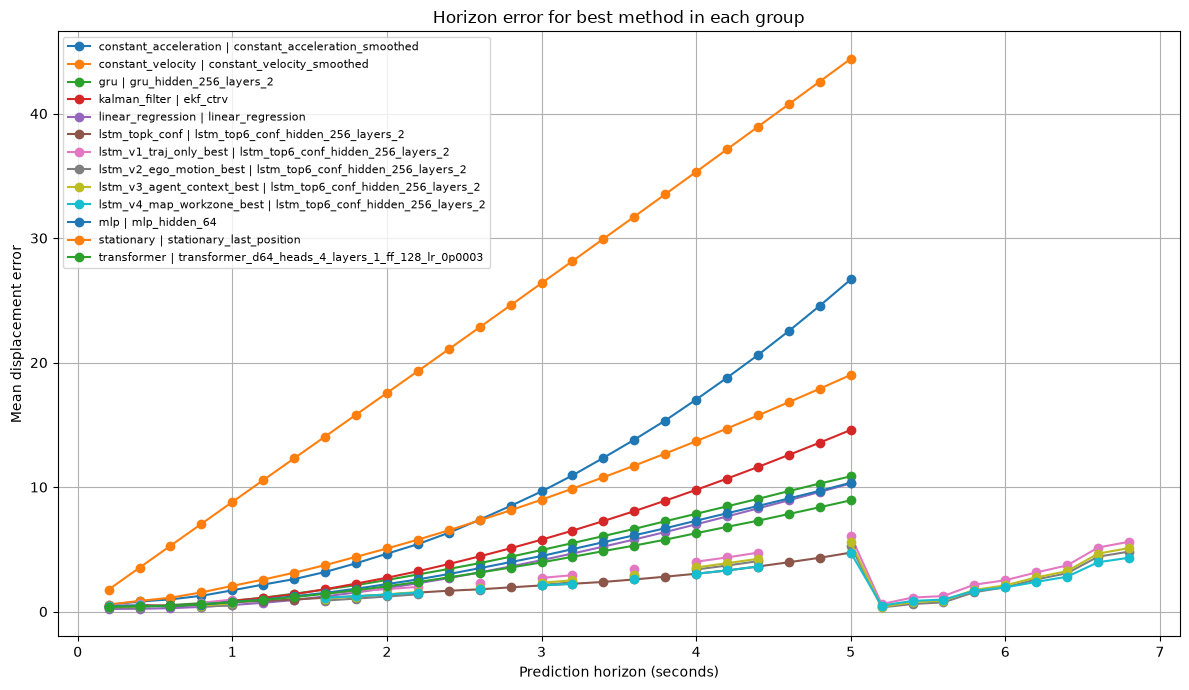

Saved: outputs/notebook_analysis_plots/best_methods_horizon_errors.png


In [7]:
# Match best_per_group method names to horizon rows
best_keys = set(zip(best_per_group["method_group"], best_per_group["method"]))

horizon_best = horizon_results[
    horizon_results.apply(lambda r: (r["method_group"], r["method"]) in best_keys, axis=1)
].copy()

plt.figure(figsize=(12, 7))

for _, row in horizon_best.iterrows():
    label = f"{row['method_group']} | {row['method']}"
    errors = row[horizon_cols].astype(float).values
    plt.plot(horizon_times, errors, marker="o", label=label)

plt.xlabel("Prediction horizon (seconds)")
plt.ylabel("Mean displacement error")
plt.title("Horizon error for best method in each group")
plt.legend(fontsize=8)
plt.grid(True)
plt.tight_layout()

save_path = PLOT_DIR / "best_methods_horizon_errors.png"
plt.savefig(save_path, dpi=200)
plt.show()

print("Saved:", save_path)

In [8]:
ablation_files = sorted(RESULTS_ROOT.glob("lstm_v*_best/*_summary.csv"))

ablation_rows = []

for path in ablation_files:
    df = pd.read_csv(path)
    df.insert(0, "feature_version", path.parent.name)
    ablation_rows.append(df)

if not ablation_rows:
    raise RuntimeError("No ablation summary files found. Run lstm_v*_best first.")

ablation = pd.concat(ablation_rows, ignore_index=True)

version_order = {
    "lstm_v1_traj_only_best": 1,
    "lstm_v2_ego_motion_best": 2,
    "lstm_v3_agent_context_best": 3,
    "lstm_v4_map_workzone_best": 4,
}

version_name = {
    "lstm_v1_traj_only_best": "V1 trajectory only",
    "lstm_v2_ego_motion_best": "V2 ego motion",
    "lstm_v3_agent_context_best": "V3 ego + agents",
    "lstm_v4_map_workzone_best": "V4 ego + agents + map/WZ",
}

ablation["version_order"] = ablation["feature_version"].map(version_order)
ablation["version_label"] = ablation["feature_version"].map(version_name)

ablation = ablation.sort_values("version_order")

cols = [
    "version_label",
    "method",
    "min_ade",
    "min_fde",
    "conf_ade",
    "conf_fde",
    "num_samples",
]

print("LSTM FEATURE ABLATION RESULTS")
display(ablation[cols])

ablation.to_csv(OUTPUT_ROOT / "lstm_feature_ablation_best_summary_notebook.csv", index=False)
print("Saved:", OUTPUT_ROOT / "lstm_feature_ablation_best_summary_notebook.csv")

LSTM FEATURE ABLATION RESULTS


,version_label,method,min_ade,min_fde,conf_ade,conf_fde,num_samples
0,V1 trajectory only,lstm_top6_conf_hidden_256_layers_2,2.614684,5.490086,6.434547,15.064580,1131
1,V2 ego motion,lstm_top6_conf_hidden_256_layers_2,2.064643,4.850482,4.632413,12.441382,1131
2,V3 ego + agents,lstm_top6_conf_hidden_256_layers_2,2.228301,5.099242,4.527508,11.673483,1131
3,V4 ego + agents + map/WZ,lstm_top6_conf_hidden_256_layers_2,2.011838,4.174666,4.974311,11.734148,1131


Saved: outputs/lstm_feature_ablation_best_summary_notebook.csv


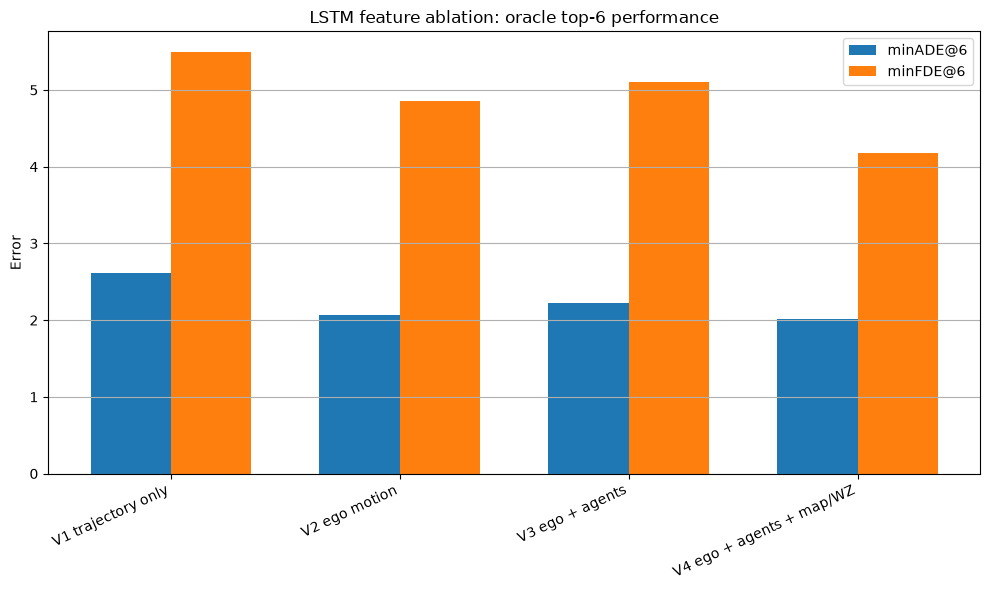

Saved: outputs/notebook_analysis_plots/lstm_feature_ablation_minade_minfde.png


In [9]:
plt.figure(figsize=(10, 6))

x = np.arange(len(ablation))
width = 0.35

plt.bar(x - width / 2, ablation["min_ade"], width, label="minADE@6")
plt.bar(x + width / 2, ablation["min_fde"], width, label="minFDE@6")

plt.xticks(x, ablation["version_label"], rotation=25, ha="right")
plt.ylabel("Error")
plt.title("LSTM feature ablation: oracle top-6 performance")
plt.legend()
plt.grid(axis="y")
plt.tight_layout()

save_path = PLOT_DIR / "lstm_feature_ablation_minade_minfde.png"
plt.savefig(save_path, dpi=200)
plt.show()

print("Saved:", save_path)

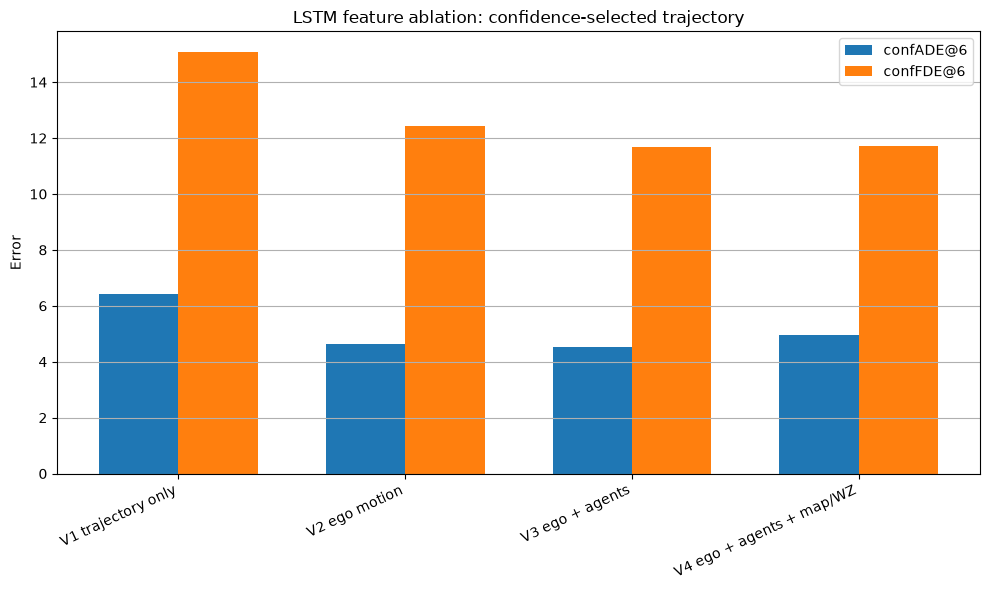

Saved: outputs/notebook_analysis_plots/lstm_feature_ablation_confade_conffde.png


In [10]:
plt.figure(figsize=(10, 6))

x = np.arange(len(ablation))
width = 0.35

plt.bar(x - width / 2, ablation["conf_ade"], width, label="confADE@6")
plt.bar(x + width / 2, ablation["conf_fde"], width, label="confFDE@6")

plt.xticks(x, ablation["version_label"], rotation=25, ha="right")
plt.ylabel("Error")
plt.title("LSTM feature ablation: confidence-selected trajectory")
plt.legend()
plt.grid(axis="y")
plt.tight_layout()

save_path = PLOT_DIR / "lstm_feature_ablation_confade_conffde.png"
plt.savefig(save_path, dpi=200)
plt.show()

print("Saved:", save_path)

In [11]:
data = np.load(DATA_PATH, allow_pickle=True)

X = data["X"]
feature_names = list(data["feature_names"])

v2_per_sample_path = RESULTS_ROOT / "lstm_v2_ego_motion_best" / "lstm_top6_conf_hidden_256_layers_2_per_sample.csv"
v4_per_sample_path = RESULTS_ROOT / "lstm_v4_map_workzone_best" / "lstm_top6_conf_hidden_256_layers_2_per_sample.csv"

v2 = pd.read_csv(v2_per_sample_path).rename(
    columns={
        "min_ade": "v2_min_ade",
        "min_fde": "v2_min_fde",
        "conf_ade": "v2_conf_ade",
        "conf_fde": "v2_conf_fde",
    }
)

v4 = pd.read_csv(v4_per_sample_path).rename(
    columns={
        "min_ade": "v4_min_ade",
        "min_fde": "v4_min_fde",
        "conf_ade": "v4_conf_ade",
        "conf_fde": "v4_conf_fde",
    }
)

sub_df = v2[
    ["sample_idx", "v2_min_ade", "v2_min_fde", "v2_conf_ade", "v2_conf_fde"]
].merge(
    v4[
        ["sample_idx", "v4_min_ade", "v4_min_fde", "v4_conf_ade", "v4_conf_fde"]
    ],
    on="sample_idx"
)

def has_feature_any_timestep(feature_name, sample_indices):
    col = feature_names.index(feature_name)
    return X[sample_indices, :, col].max(axis=1) > 0

sample_indices = sub_df["sample_idx"].values.astype(int)

sub_df["has_cone"] = has_feature_any_timestep("has_cone", sample_indices)
sub_df["has_worker"] = has_feature_any_timestep("has_worker", sample_indices)
sub_df["has_warning"] = has_feature_any_timestep("has_warning", sample_indices)
sub_df["has_wz_corners"] = has_feature_any_timestep("has_wz_corners", sample_indices)

sub_df["has_cone_or_worker"] = sub_df["has_cone"] | sub_df["has_worker"]
sub_df["has_cone_worker_warning"] = sub_df["has_cone"] | sub_df["has_worker"] | sub_df["has_warning"]
sub_df["no_cone_worker_warning"] = ~sub_df["has_cone_worker_warning"]

sub_df["v4_gain_min_ade"] = sub_df["v2_min_ade"] - sub_df["v4_min_ade"]
sub_df["v4_gain_min_fde"] = sub_df["v2_min_fde"] - sub_df["v4_min_fde"]
sub_df["v4_gain_conf_ade"] = sub_df["v2_conf_ade"] - sub_df["v4_conf_ade"]
sub_df["v4_gain_conf_fde"] = sub_df["v2_conf_fde"] - sub_df["v4_conf_fde"]

print("Merged per-sample rows:", len(sub_df))
display(sub_df.head())

Merged per-sample rows: 1131


,sample_idx,v2_min_ade,v2_min_fde,v2_conf_ade,v2_conf_fde,v4_min_ade,v4_min_fde,v4_conf_ade,v4_conf_fde,has_cone,has_worker,has_warning,has_wz_corners,has_cone_or_worker,has_cone_worker_warning,no_cone_worker_warning,v4_gain_min_ade,v4_gain_min_fde,v4_gain_conf_ade,v4_gain_conf_fde
0,226,1.461609,4.632446,1.461609,5.922315,1.897558,4.177787,3.234065,7.352540,True,True,True,False,True,True,False,-0.435949,0.454659,-1.772456,-1.430224
1,227,1.561189,1.235956,2.756131,10.372959,1.075910,2.779832,3.980699,6.247058,True,True,True,False,True,True,False,0.485279,-1.543875,-1.224568,4.125901
2,228,1.787074,4.228105,3.695393,12.869961,0.981985,1.902598,2.773439,2.525732,True,True,True,False,True,True,False,0.805090,2.325506,0.921954,10.344229
3,229,1.348180,3.104966,1.348180,3.104966,0.883450,0.972233,1.624474,0.972233,True,True,True,False,True,True,False,0.464729,2.132733,-0.276295,2.132733
4,230,1.327066,4.452307,2.468226,9.176318,0.648785,1.867863,0.648785,1.867863,True,True,True,False,True,True,False,0.678281,2.584443,1.819441,7.308455


In [12]:
def summarize_boolean_group(df, feature_col, label):
    rows = []

    for value, group_name in [(True, "present"), (False, "absent")]:
        mask = df[feature_col] == value
        g = df[mask]

        if len(g) == 0:
            continue

        rows.append({
            "group": label,
            "status": group_name,
            "n": len(g),

            "V2 minADE": g["v2_min_ade"].mean(),
            "V4 minADE": g["v4_min_ade"].mean(),
            "V4 gain minADE": g["v4_gain_min_ade"].mean(),

            "V2 minFDE": g["v2_min_fde"].mean(),
            "V4 minFDE": g["v4_min_fde"].mean(),
            "V4 gain minFDE": g["v4_gain_min_fde"].mean(),

            "V2 confADE": g["v2_conf_ade"].mean(),
            "V4 confADE": g["v4_conf_ade"].mean(),
            "V4 gain confADE": g["v4_gain_conf_ade"].mean(),

            "V2 confFDE": g["v2_conf_fde"].mean(),
            "V4 confFDE": g["v4_conf_fde"].mean(),
            "V4 gain confFDE": g["v4_gain_conf_fde"].mean(),
        })

    return rows


group_specs = [
    ("has_cone", "Cone"),
    ("has_worker", "Worker"),
    ("has_warning", "Warning"),
    ("has_wz_corners", "WZ corners"),
    ("has_cone_or_worker", "Cone or worker"),
    ("has_cone_worker_warning", "Cone/worker/warning"),
]

summary_rows = []

for col, label in group_specs:
    summary_rows.extend(summarize_boolean_group(sub_df, col, label))

subgroup_summary = pd.DataFrame(summary_rows)

print("V2 VS V4 SUBGROUP ANALYSIS")
display(subgroup_summary)

subgroup_summary.to_csv(OUTPUT_ROOT / "v2_vs_v4_subgroup_cone_worker_warning.csv", index=False)
print("Saved:", OUTPUT_ROOT / "v2_vs_v4_subgroup_cone_worker_warning.csv")

V2 VS V4 SUBGROUP ANALYSIS


,group,status,n,V2 minADE,V4 minADE,V4 gain minADE,V2 minFDE,V4 minFDE,V4 gain minFDE,V2 confADE,V4 confADE,V4 gain confADE,V2 confFDE,V4 confFDE,V4 gain confFDE
0,Cone,present,798,2.127983,1.883352,0.244630,4.977048,3.938432,1.038616,4.644494,4.878096,-0.233602,12.200574,11.756773,0.443801
1,Cone,absent,333,1.912855,2.319740,-0.406885,4.547179,4.740775,-0.193595,4.603464,5.204879,-0.601416,13.018453,11.679929,1.338524
2,Worker,present,798,2.127983,1.883352,0.244630,4.977048,3.938432,1.038616,4.644494,4.878096,-0.233602,12.200574,11.756773,0.443801
3,Worker,absent,333,1.912855,2.319740,-0.406885,4.547179,4.740775,-0.193595,4.603464,5.204879,-0.601416,13.018453,11.679929,1.338524
4,Warning,present,961,2.086854,1.834647,0.252207,4.894164,3.731733,1.162430,4.628506,4.837384,-0.208878,12.381064,11.505459,0.875606
5,Warning,absent,170,1.939082,3.013487,-1.074406,4.603551,6.678536,-2.074985,4.654501,5.748348,-1.093847,12.782352,13.026912,-0.244560
6,WZ corners,present,333,1.912855,2.319740,-0.406885,4.547179,4.740775,-0.193595,4.603464,5.204879,-0.601416,13.018453,11.679929,1.338524
7,WZ corners,absent,798,2.127983,1.883352,0.244630,4.977048,3.938432,1.038616,4.644494,4.878096,-0.233602,12.200574,11.756773,0.443801
8,Cone or worker,present,798,2.127983,1.883352,0.244630,4.977048,3.938432,1.038616,4.644494,4.878096,-0.233602,12.200574,11.756773,0.443801
9,Cone or worker,absent,333,1.912855,2.319740,-0.406885,4.547179,4.740775,-0.193595,4.603464,5.204879,-0.601416,13.018453,11.679929,1.338524


Saved: outputs/v2_vs_v4_subgroup_cone_worker_warning.csv


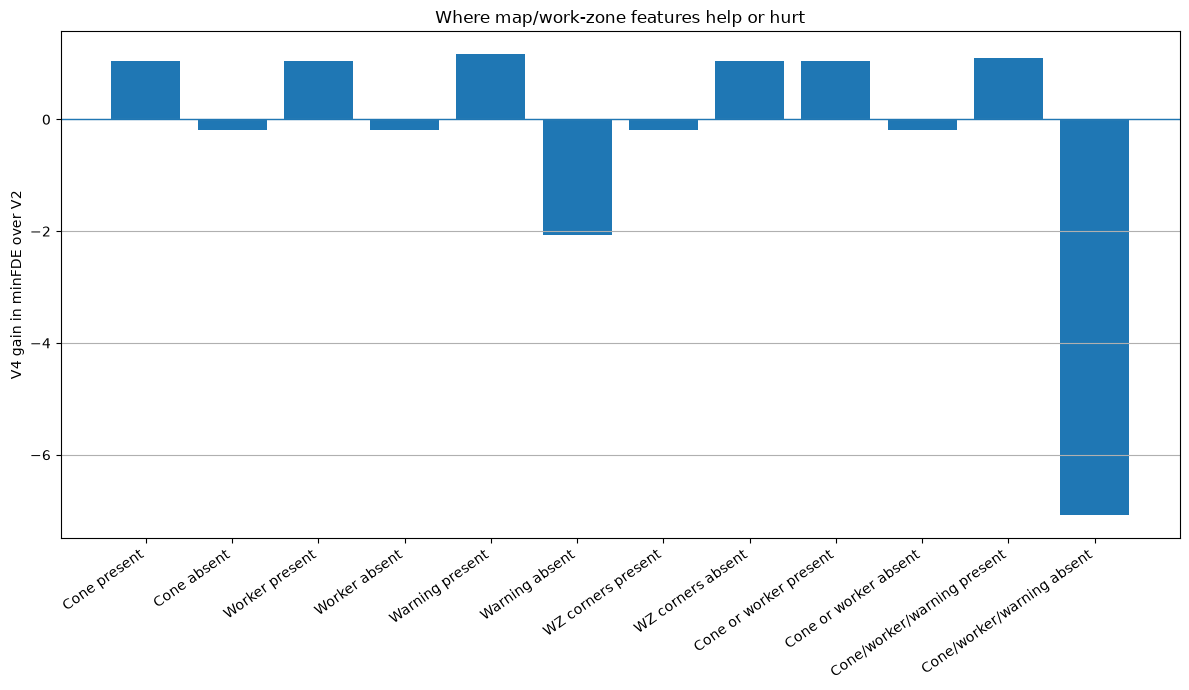

Saved: outputs/notebook_analysis_plots/v4_gain_minfde_subgroups.png


In [13]:
plot_sub = subgroup_summary.copy()
plot_sub["label"] = plot_sub["group"] + " " + plot_sub["status"]

plt.figure(figsize=(12, 7))

x = np.arange(len(plot_sub))

plt.bar(x, plot_sub["V4 gain minFDE"])

plt.axhline(0, linewidth=1)
plt.xticks(x, plot_sub["label"], rotation=35, ha="right")
plt.ylabel("V4 gain in minFDE over V2")
plt.title("Where map/work-zone features help or hurt")
plt.grid(axis="y")
plt.tight_layout()

save_path = PLOT_DIR / "v4_gain_minfde_subgroups.png"
plt.savefig(save_path, dpi=200)
plt.show()

print("Saved:", save_path)

In [ ]:
focused = subgroup_summary[
    subgroup_summary["group"].isin(["Cone/worker/warning", "Cone or worker", "WZ corners"])
].copy()

cols = [
    "group",
    "status",
    "n",
    "V2 minADE",
    "V4 minADE",
    "V4 gain minADE",
    "V2 minFDE",
    "V4 minFDE",
    "V4 gain minFDE",
]

print("FOCUSED WORK-ZONE OBJECT SUBGROUPS")
display(focused[cols])

In [3]:
import pandas as pd
from pathlib import Path

paths = {
    "workzone_v2_only": Path("outputs/results_workzone/lstm_v2_ego_motion_best/lstm_v2_ego_motion_best_summary.csv"),
    "expA_mixed": Path("outputs/results_workzone/lstm_expA_mixed_nuscenes_workzone_v2/lstm_expA_mixed_nuscenes_workzone_v2_summary.csv"),
    "expB_finetune_wz": Path("outputs/results_workzone/lstm_expB_finetune_workzone_v2/lstm_topk_conf_summary.csv"),
}

rows = []

for name, path in paths.items():
    if not path.exists():
        print("Missing:", name, path)
        continue

    df = pd.read_csv(path)
    df.insert(0, "experiment", name)
    rows.append(df)

if not rows:
    raise RuntimeError("No result files found.")

out = pd.concat(rows, ignore_index=True)

cols = [
    "experiment",
    "method",
    "min_ade",
    "min_fde",
    "conf_ade",
    "conf_fde",
    "num_samples",
]

out_display = out[cols]

display(out_display)

print(out_display.to_string(index=False))

,experiment,method,min_ade,min_fde,conf_ade,conf_fde,num_samples
0,workzone_v2_only,lstm_top6_conf_hidden_256_layers_2,2.064643,4.850482,4.632413,12.441382,1131
1,expA_mixed,lstm_top6_conf_hidden_256_layers_2,2.035371,4.695936,4.554463,12.229887,1131
2,expB_finetune_wz,lstm_top6_conf_hidden_256_layers_2,2.074210,5.219242,4.782125,12.604341,1131


      experiment                             method  min_ade  min_fde  conf_ade  conf_fde  num_samples
workzone_v2_only lstm_top6_conf_hidden_256_layers_2 2.064643 4.850482  4.632413 12.441382         1131
      expA_mixed lstm_top6_conf_hidden_256_layers_2 2.035371 4.695936  4.554463 12.229887         1131
expB_finetune_wz lstm_top6_conf_hidden_256_layers_2 2.074210 5.219242  4.782125 12.604341         1131
